# SHRED on ME4OH full-field OFAM3 SST data

Note: Assumptions as of 30/06/26
- OFAM3 data is stored for Thursdays across the 1979-2014 time period.
- Pending confirmation from the ME4OH team, I have assumed that the data is the full-field SST values generated by the simulator model (OFAM3) averaged across a calendar week

In [1]:
from collections import Counter

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.metrics import structural_similarity as SSI
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

# Local imports
import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py 
from Data.preprocess_sst_ofam3_shred import create_shred_sequences, load_files, split_ordered_data
from Data.preprocess_sst_ofam3_shred import NA_DATA_PATH
from Data.load_sst_en411_data import crop_df_to_area
from helper_functions.evaluation import mask_array_by_lat_long  #, ssi_by_image
from plotting_functions import plot_sst_map, plot_compare_sst_recon

np.random.seed(42)

## SHRED preprocessing

In [2]:
# Experiment 1: 5 randomly located sensors
num_sensors = 5
lags = 52

# Experiment 2: average number of sensors per week in ME4OH SST dataset is 1059 (increases over time)
# num_sensors = 1059
# lags = 52

In [3]:
# Load and reformat data
data, dates, lats, longs = load_files()

Loading data: 100%|██████████| 1878/1878 [00:09<00:00, 200.13it/s]


In [4]:
print("Preprocessing data...")
train_data, val_data, test_data, test_dates = split_ordered_data(data, dates)

# Normalise data
sc = MinMaxScaler()
sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
train_transformed = sc.transform(train_data)  
val_transformed = sc.transform(val_data)
test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
sensor_coords=(longs[sensor_locations], lats[sensor_locations])
# print(f"Sensor location indexes will be: {sensor_locations}")

# Build sequences
train_dataset = create_shred_sequences(train_transformed, sensor_locations, lags=lags)
val_dataset = create_shred_sequences(val_transformed, sensor_locations, lags=lags)
test_dataset = create_shred_sequences(test_transformed, sensor_locations, lags=lags)

# Get dates corresponding to the predictions made by the model
test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

Preprocessing data...


### STOP HERE if loading saved data

In [5]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# shred = models.SHRED(num_sensors, len(lats), hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
# validation_errors = models.fit(shred, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

In [6]:
# test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
# test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
# print('Test Reconstruction Error: ')
# print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

In [7]:
# np.save(f"Reconstructions/recons_n{num_sensors}_l{lags}", test_recons)
# np.save(f"Reconstructions/truth_n{num_sensors}_l{lags}", test_ground_truth)

### START HERE

In [8]:
test_recons = np.load(f"Reconstructions/recons_n{num_sensors}_l{lags}.npy")
test_ground_truth = np.load(f"Reconstructions/truth_n{num_sensors}_l{lags}.npy")

Date: 2013-07-11


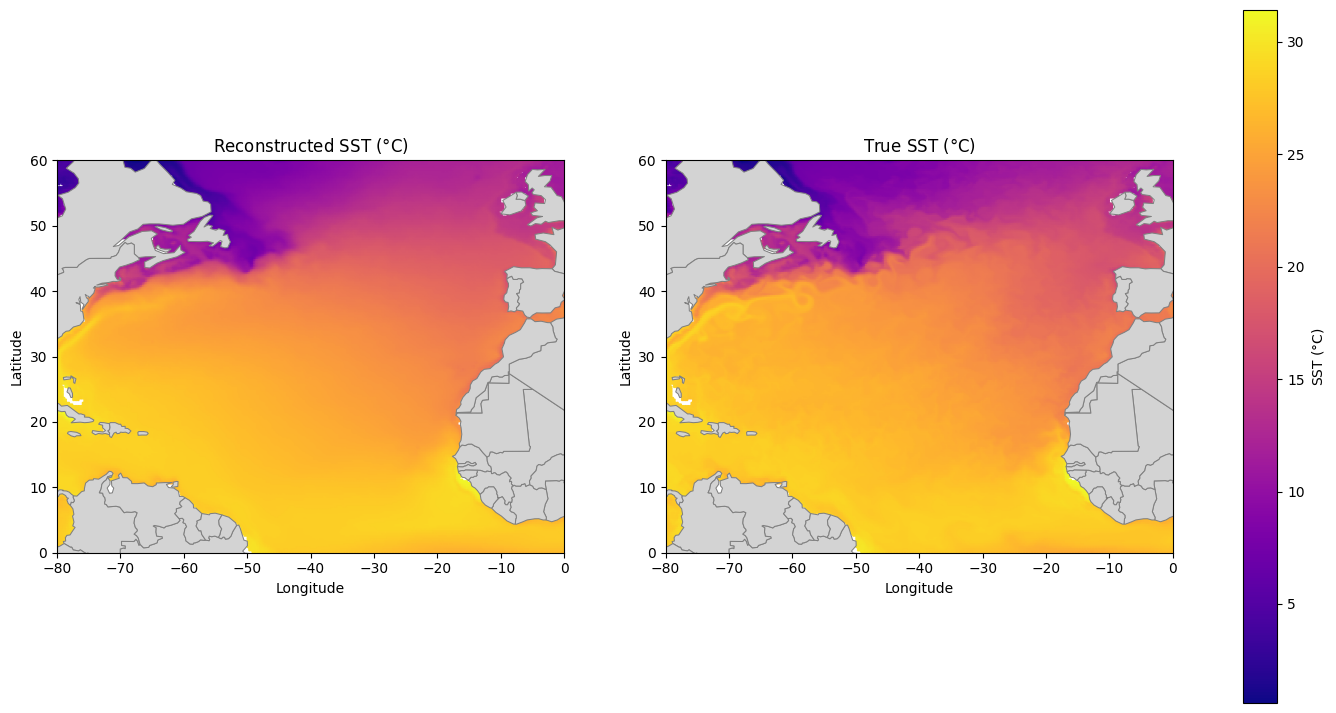

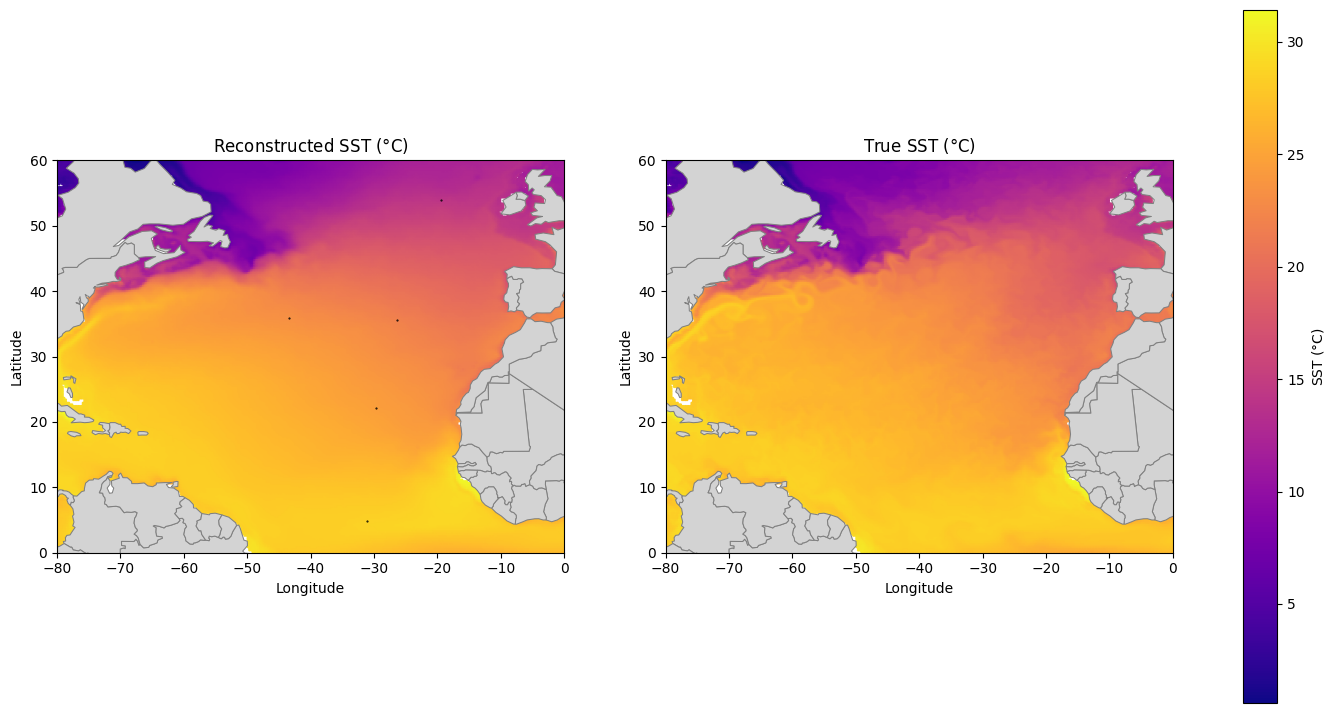

In [9]:
for i in np.random.choice(range(len(test_recons)), 1):
    recon_df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": test_recons[i]
    })
    true_df = pd.read_csv(f"{NA_DATA_PATH}{test_lag_dates[i]}.csv")
    print(f"Date: {test_lag_dates[i]}")
    plot_compare_sst_recon(recon_df, true_df, area="NA")
    plot_compare_sst_recon(recon_df, true_df, area="NA", sensor_coords=sensor_coords)

In [10]:
# plot_sst_map(recon_df, test_lag_dates[i], min_sst=min(recon_df.SST), max_sst=max(recon_df.SST), area='NA', sensor_coords=sensor_coords)

In [11]:
# plot_sst_map(true_df, date, min(true_df.SST), max(true_df.SST), area='NA')

### Evaluation

Structural Similarity Index: [[1]](https://scikit-image.org/docs/stable/api/skimage.metrics.html#skimage.metrics.structural_similarity) [[2]](https://ieeexplore.ieee.org/document/4775883)

In [12]:
rmse = np.sqrt(MSE(y_pred=test_recons, y_true=test_ground_truth))
mae = MAE(y_pred=test_recons, y_true=test_ground_truth)
r2 = r2_score(y_pred=test_recons, y_true=test_ground_truth)
print(f"RMSE:\t{rmse:.3f}")
print(f"MAE:\t{mae:.3f}")
print(f"R2:\t{r2:.3f}")

RMSE:	0.732
MAE:	0.477
R2:	0.870


In [13]:
ssi = np.mean([SSI(test_ground_truth[i], test_recons[i], 
                   data_range=(max(test_recons[i].max(), test_ground_truth[i].max()) - min(test_recons[i].min(), test_ground_truth[i].min())))
                   for i in range(len(test_recons))])
print(f"Average SSI:\t{ssi:.3f}")

Average SSI:	0.950


In [14]:
# ssi_by_images = ssi_by_image(test_recons, test_ground_truth, lats, longs, plot_images=True)
# ssi_by_images_mean = np.mean(ssi_by_images)
# print(f"Average SSI (by images):\t{ssi_by_images_mean:.3f}")

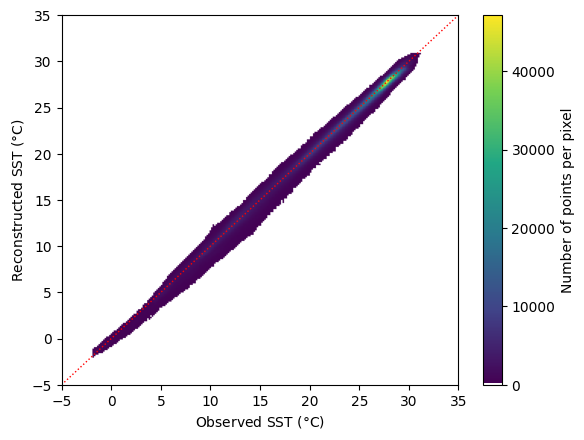

In [37]:
import mpl_scatter_density # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap

# https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density

# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

def using_mpl_scatter_density(fig, x, y):
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    density = ax.scatter_density(x, y, cmap=white_viridis)
    ax.set_xlim(-5, 35)
    ax.set_ylim(-5, 35)
    fig.colorbar(density, label='Number of points per pixel')

fig = plt.figure()
x = test_ground_truth.reshape(-1)
y = test_recons.reshape(-1)
using_mpl_scatter_density(fig, x, y)
plt.plot([-5, 35], [-5, 35], ':', lw=1, c='r')
plt.xlabel("Observed SST ($\\degree$C)")
plt.ylabel("Reconstructed SST ($\\degree$C)")
plt.show()

Text(0.5, 1.0, '2014-11-13')

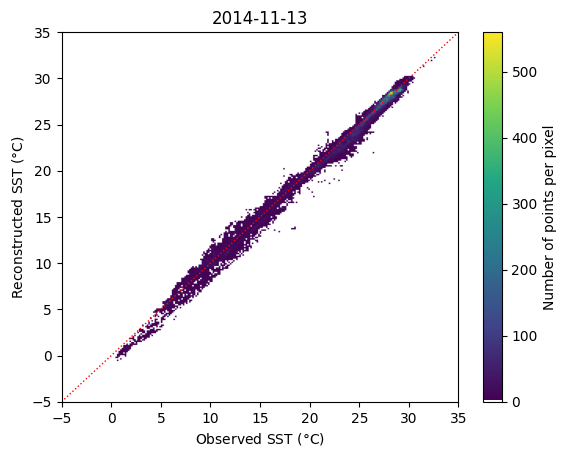

In [38]:
fig = plt.figure()
i = 177
# plt.scatter(test_ground_truth[i], test_recons[i], alpha=0.25)
using_mpl_scatter_density(fig, test_ground_truth[i].reshape(-1), test_recons[i].reshape(-1))
plt.plot([-5, 35], [-5, 35], ':', lw=1, c='r')
plt.xlabel("Observed SST ($\\degree$C)")
plt.ylabel("Reconstructed SST ($\\degree$C)")
plt.title(f"{test_lag_dates[i]}")

In [ ]:
# lats = np.array([20.0, 31.0, 33.0, 50.0, 55.0])
# longs = np.array([-80.0, -80.0, -34.0, -34.0, -34.0])
# data = np.array([[24.0, 25.0, 26.0, 27.0, 28.0], [24.0, 25.0, 26.0, 27.0, 28.0], [24.0, 25.0, 26.0, 27.0, 28.0]])
# data = mask_array_by_lat_long(test_recons, lats, longs)

In [ ]:
difference = test_recons - test_ground_truth
for i in [0]: # range(0, len(test_recons), 10):  # np.random.choice(range(len(test_recons)), 1):
    diff_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": difference[i]
        })
    recon_df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": test_recons[i]
    })
    true_df = pd.read_csv(f"{NA_DATA_PATH}{test_lag_dates[i]}.csv")
    # plot_sst_map(diff_df, title=f"Difference map for {test_dates[i]}", min_sst=-5, max_sst=5, area="NA", cmap='bwr')
    print(f"Date: {test_lag_dates[i]}")
    plot_compare_sst_recon(recon_df, true_df, diff_data=diff_df, area="NA", sensor_coords=sensor_coords)

    gs_recon_df = crop_df_to_area(recon_df, "GS", "Latitude")
    gs_true_df = crop_df_to_area(true_df, "GS", "Latitude")
    gs_diff_df = crop_df_to_area(diff_df, "GS", "Latitude")
    
    # plot_compare_sst_recon(gs_recon_df, gs_true_df, diff_data=gs_diff_df, area='GS')

### Average difference between reconstruction and truth across whole test set

In [ ]:
avg_difference = [np.mean(d) for d in difference]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(test_lag_dates, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')

In [ ]:
# For Gulf Stream only:
GS_data = mask_array_by_lat_long(difference, lats, longs)
GS_data = [d[~np.isnan(d)] for d in GS_data]

In [ ]:
avg_difference = [np.mean(d) for d in GS_data]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(test_lag_dates, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')

In [ ]:
GS_test_data = mask_array_by_lat_long(test_recons, lats, longs)
GS_truth_data = mask_array_by_lat_long(test_ground_truth, lats, longs)
GS_test_data = [d[~np.isnan(d)] for d in GS_test_data]
GS_truth_data = [d[~np.isnan(d)] for d in GS_truth_data]

In [ ]:
rmse = np.sqrt(MSE(y_pred=GS_test_data, y_true=GS_truth_data))
mae = MAE(y_pred=GS_test_data, y_true=GS_truth_data)
r2 = r2_score(y_pred=GS_test_data, y_true=GS_truth_data)
print(f"RMSE:\t{rmse:.3f}")
print(f"MAE:\t{mae:.3f}")
print(f"R2:\t{r2:.3f}")

In [ ]:
ssi = np.mean([SSI(GS_truth_data[i], GS_test_data[i], data_range=test_recons[i].max() -  test_recons[i].min()) for i in range(len(test_recons))])
print(f"Average SSI:\t{ssi:.3f}")

### Differences between test reconstructions
Verifying that not just getting identical reconstructions
- Not every point in scatter plot is 0 - so there is difference!

Also see: clear seasonality in the generations being produced!
- Sensible that there's a clear difference when spring to autumn are compared

In [ ]:
# avg_diff = []
# date1 = []
# date2 = []
# for i in range(len(test_recons)):
#     for j in range(len(test_recons)):
#         date1.append(test_dates[i])
#         date2.append(test_dates[j])
#         avg_diff.append(np.mean(test_recons[i] - test_recons[j]))

# diff_df = pd.DataFrame({
#     "Date 1": date1,
#     "Date 2": date2,
#     "Average difference ($\\degree$C)": avg_diff
# })

In [ ]:
# s = diff_df.plot.scatter(x="Date 1", y="Date 2", c="Average difference ($\\degree$C)", cmap='rainbow')
# plt.xticks(rotation=90)
# plt.grid()

In [ ]:
# Santity check that all reconstructions aren't identical
bool_check = [[np.array_equal(recon1,recon2) for recon2 in test_recons] for recon1 in test_recons]

In [ ]:
# Check that only ever 1 True value (on diagonal)
Counter([Counter(row) == Counter({False: 182, True: 1}) for row in bool_check])
# Expected output: Counter({True: 183})

In [ ]:
# Check all diagonals are true
Counter(np.diag(bool_check))
# Expected output: Counter({True: 183})

In [ ]:
plt.matshow(bool_check)
# Expected output: Only diagonal of matrix is True (yellow), rest is False (purple)